<a href="https://colab.research.google.com/github/fkhaaan/computer_vision/blob/main/data_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA** **CRAPING**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.2/105.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.2/258.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.4/94.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0

Output()

Output()

Found: 105
Downloaded: 105
Flat dataset folder: /content/pilaf_images_flat
Total flat images: 105


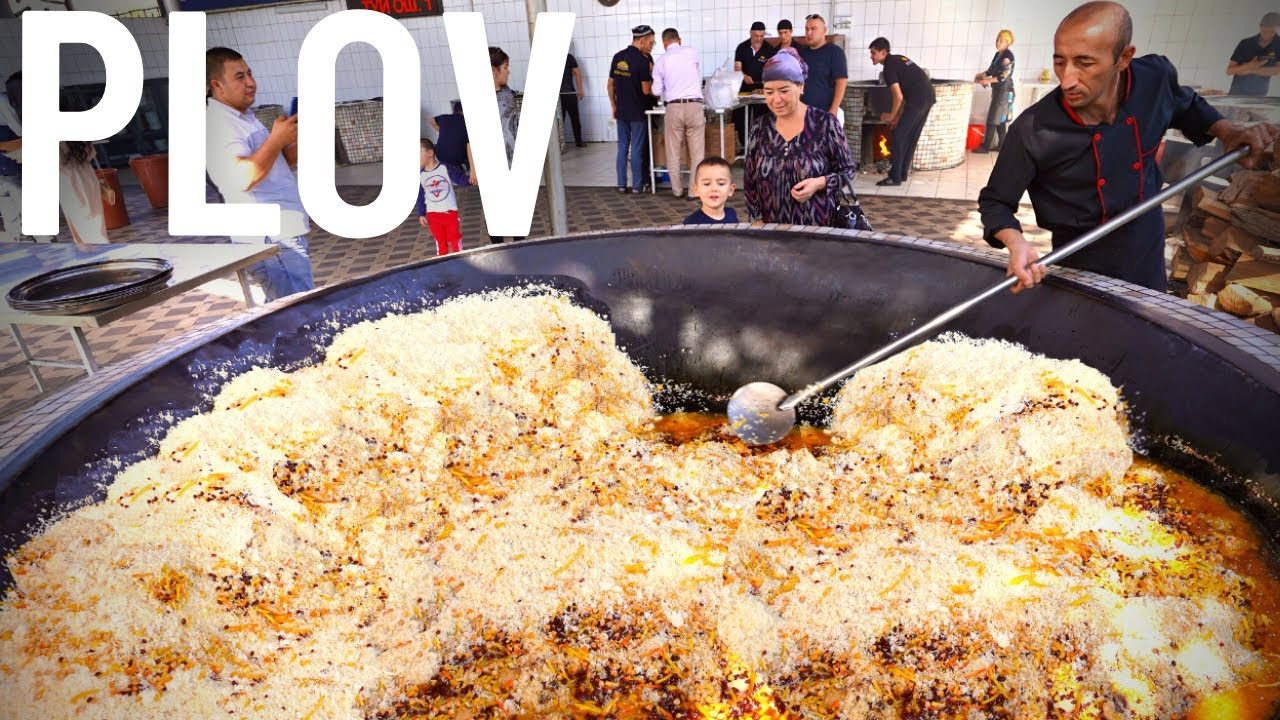

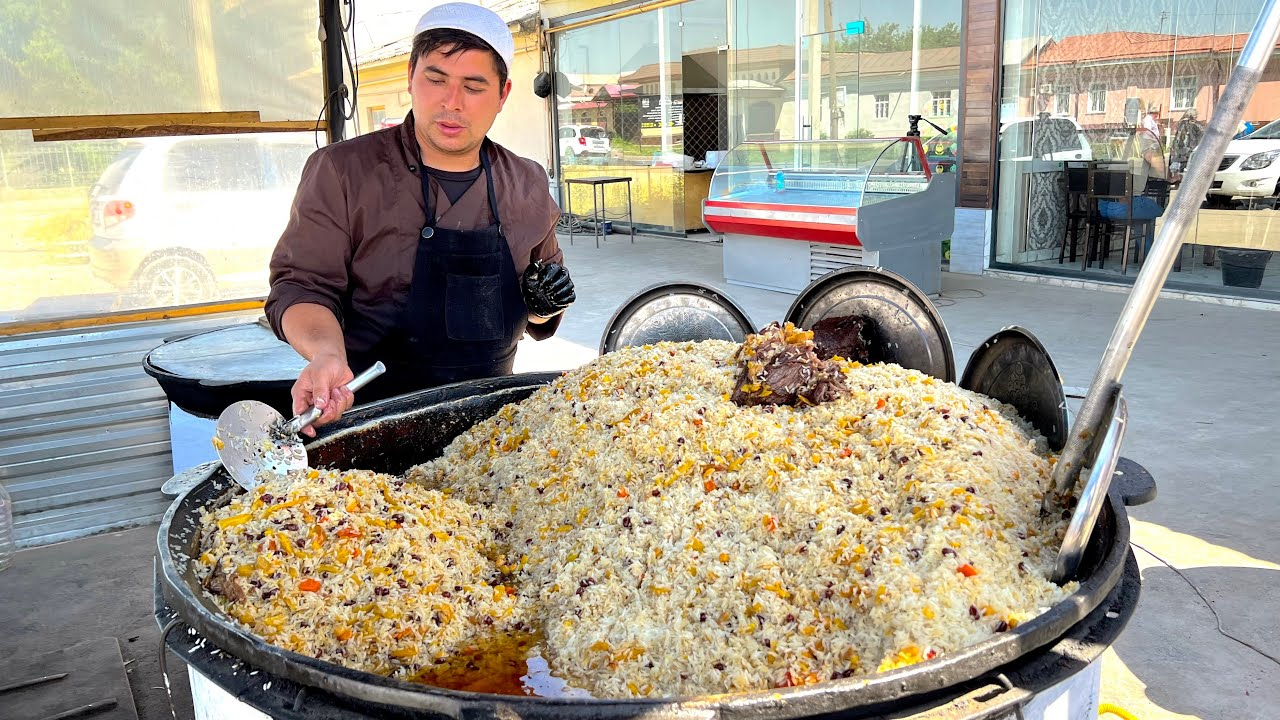

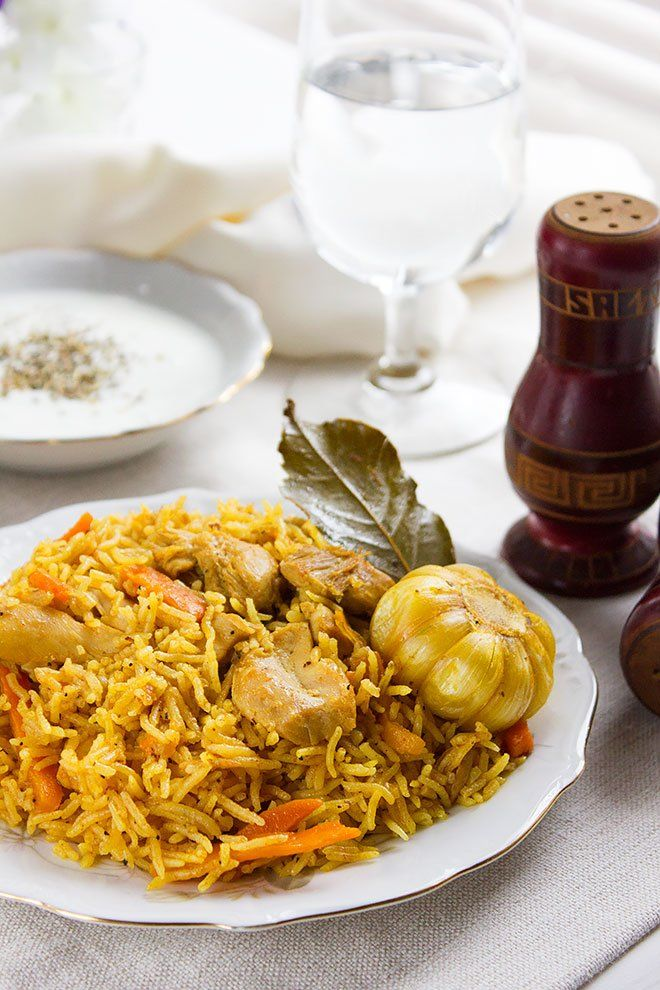

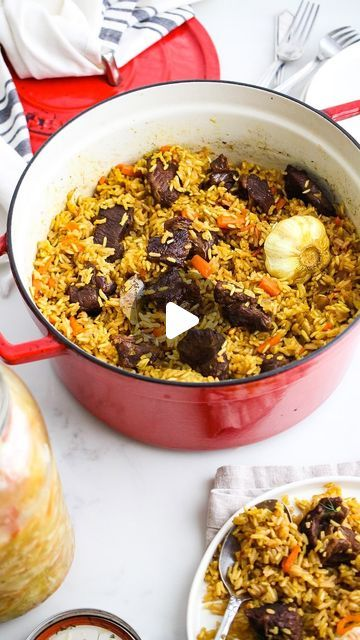

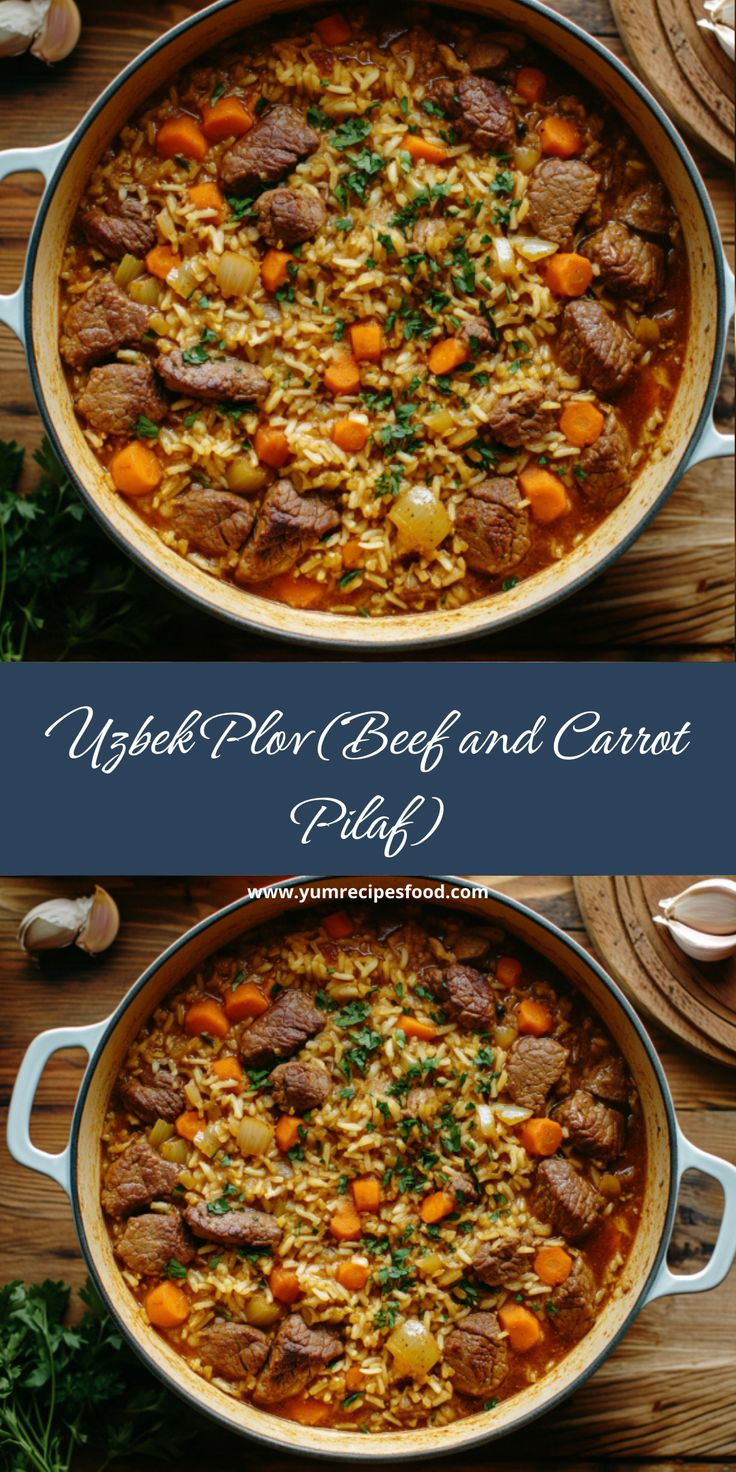

In [ ]:
!pip install -q pyimagedl

from imagedl import imagedl
from pathlib import Path
import shutil
from IPython.display import Image, display

keyword = "uzbek pilaf plov food"
limit = 100
output_dir = "/content/pilaf_images"

client = imagedl.ImageClient(
    image_sources=["YandexImageClient"],
    init_image_clients_cfg={
        "YandexImageClient": {
            "work_dir": output_dir,
            "max_retries": 5
        }
    },
    clients_threadings={
        "YandexImageClient": 2
    }
)

search_results = client.search(
    keyword=keyword,
    search_limits_per_source={
        "YandexImageClient": limit
    }
)

downloaded_results = client.download(image_infos=search_results)

print("Found:", sum(len(v) for v in search_results.values()))
print("Downloaded:", len(downloaded_results))

source_dir = Path(output_dir)
flat_dir = Path("/content/pilaf_images_flat")
flat_dir.mkdir(parents=True, exist_ok=True)

image_files = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp", "*.gif"]:
    image_files.extend(source_dir.rglob(ext))

for index, img_path in enumerate(image_files, start=1):
    suffix = img_path.suffix.lower()
    shutil.copy(img_path, flat_dir / f"pilaf_{index:04d}{suffix}")

print("Flat dataset folder:", flat_dir)
print("Total flat images:", len(list(flat_dir.iterdir())))

for img_path in list(flat_dir.iterdir())[:5]:
    display(Image(filename=str(img_path), width=250))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil

source_dir = '/content/kebab_images/kebab shashlik food'
target_dir = '/content/drive/MyDrive/food101_dataset/kebab'

os.makedirs(target_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    src_file = os.path.join(source_dir, filename)
    dst_file = os.path.join(target_dir, filename)
    shutil.move(src_file, dst_file)

In [ ]:
import os, shutil

source_dir = '/content/pilaf_images/uzbek/pilaf'
target_dir = '/content/drive/MyDrive/food101_dataset/pilaf'

os.makedirs(target_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    src_file = os.path.join(source_dir, filename)
    dst_file = os.path.join(target_dir, filename)
    shutil.move(src_file, dst_file)

print("Pilaf rasmlari muvaffaqiyatli ko'chirildi!")

Pilaf rasmlari muvaffaqiyatli ko'chirildi!
